In [2]:
#EX1

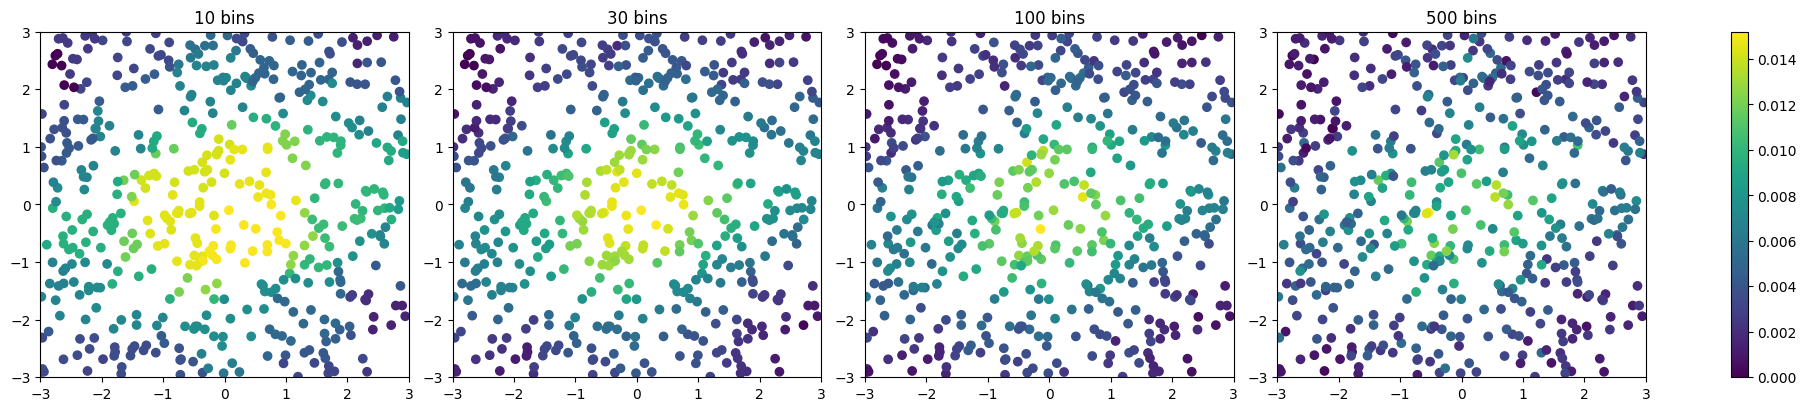

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

train_points, _ = make_blobs(
    n_samples=500,
    n_features=2,
    centers=[(0.0, 0.0)],
    cluster_std=1.0,
    random_state=7
)

raw_proj = np.random.multivariate_normal(
    mean=[0.0, 0.0],
    cov=np.eye(2),
    size=5
)
proj_dirs = raw_proj / np.linalg.norm(raw_proj, axis=1, keepdims=True)

train_proj = train_points @ proj_dirs.T

a = train_proj.min()
b = train_proj.max()
margin = 0.5 * (b - a)
r_min = a - margin
r_max = b + margin

bin_counts = [10, 30, 100, 500]

test_points = np.random.uniform(-3.0, 3.0, size=(500, 2))

fig, axes = plt.subplots(1, len(bin_counts), figsize=(18, 4), constrained_layout=True)

for ax, nb in zip(axes, bin_counts):
    prob_sets = []
    edge_sets = []

    for j in range(proj_dirs.shape[0]):
        h, edges = np.histogram(train_proj[:, j], bins=nb, range=(r_min, r_max))
        p = h.astype(float) / h.sum()
        prob_sets.append(p)
        edge_sets.append(edges)

    test_proj = test_points @ proj_dirs.T
    scores = np.zeros(test_points.shape[0])

    for i in range(test_points.shape[0]):
        vals = test_proj[i]
        local = np.empty(len(prob_sets))
        for k in range(len(prob_sets)):
            e = edge_sets[k]
            idx = np.searchsorted(e, vals[k]) - 1
            if idx < 0:
                idx = 0
            elif idx >= len(prob_sets[k]):
                idx = len(prob_sets[k]) - 1
            local[k] = prob_sets[k][idx]
        scores[i] = local.mean()

    sc = ax.scatter(test_points[:, 0], test_points[:, 1], c=scores, cmap="viridis")
    ax.set_title(f"{nb} bins")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

fig.colorbar(sc, ax=axes.ravel().tolist())
plt.show()


In [ ]:
#EX2

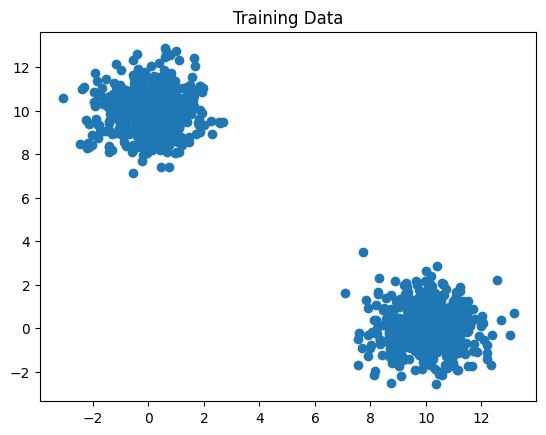

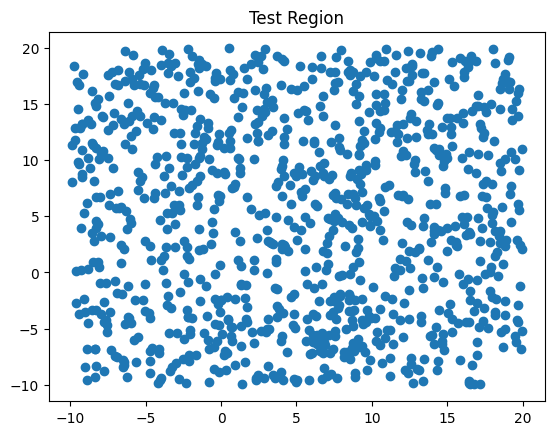

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from pyod.models.iforest import IForest
from pyod.models.dif import DIF
from pyod.models.loda import LODA

points, _ = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=[(10, 0), (0, 10)],
    cluster_std=1.0,
    random_state=30
)

plt.scatter(points[:,0], points[:,1])
plt.title("Training Data")
plt.show()

rng = np.random.default_rng(15)
test_data = rng.uniform(-10, 20, size=(1000, 2))

plt.scatter(test_data[:,0], test_data[:,1])
plt.title("Test Region")
plt.show()


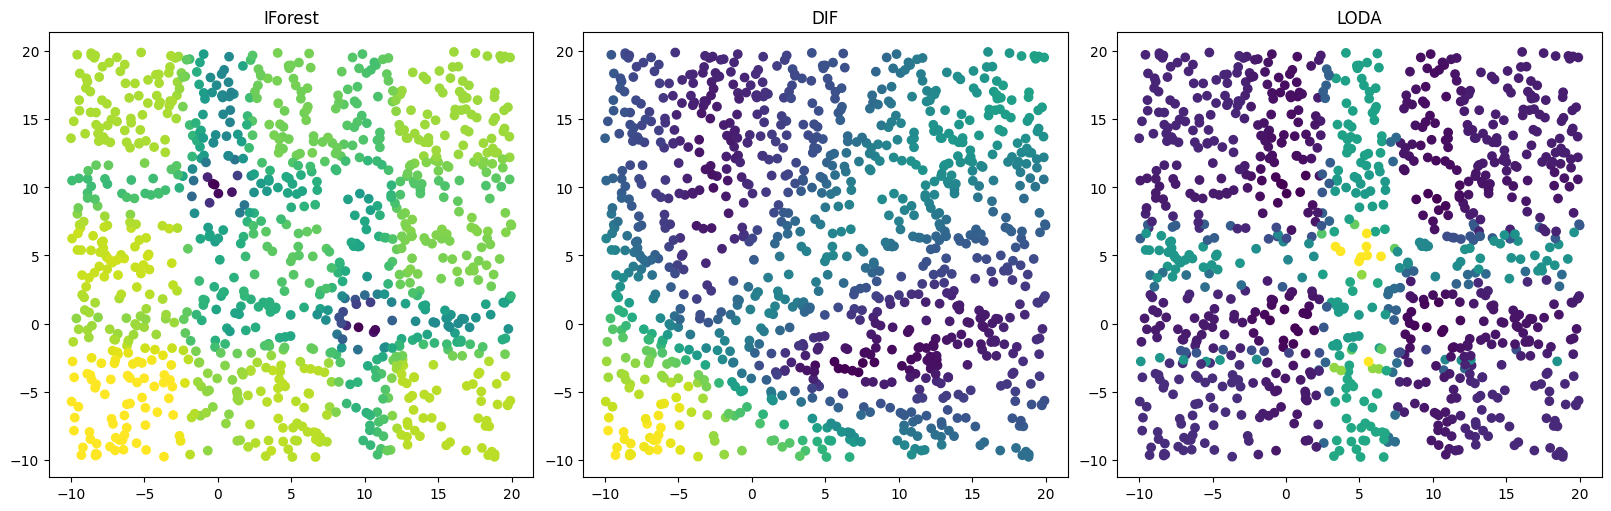

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

axes[0].scatter(test_2d[:,0], test_2d[:,1], c=scores_if, cmap="viridis")
axes[0].set_title("IForest")

axes[1].scatter(test_2d[:,0], test_2d[:,1], c=scores_dif, cmap="viridis")
axes[1].set_title("DIF")

axes[2].scatter(test_2d[:,0], test_2d[:,1], c=scores_loda, cmap="viridis")
axes[2].set_title("LODA")

plt.show()


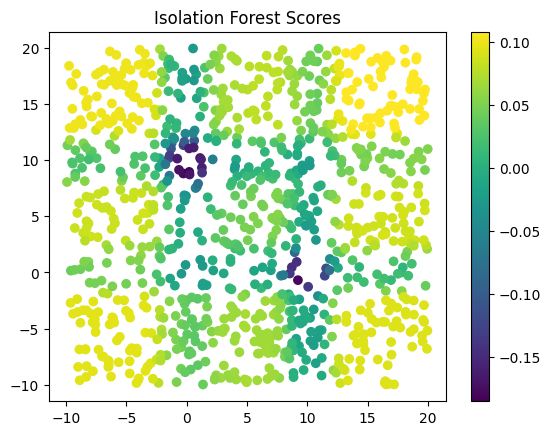

In [22]:
iso = IForest(contamination=0.02)
iso.fit(points)
iso_scores = iso.decision_function(test_data)
plt.scatter(test_data[:,0], test_data[:,1], c=iso_scores, cmap="viridis")
plt.colorbar()
plt.title("Isolation Forest Scores")
plt.show()

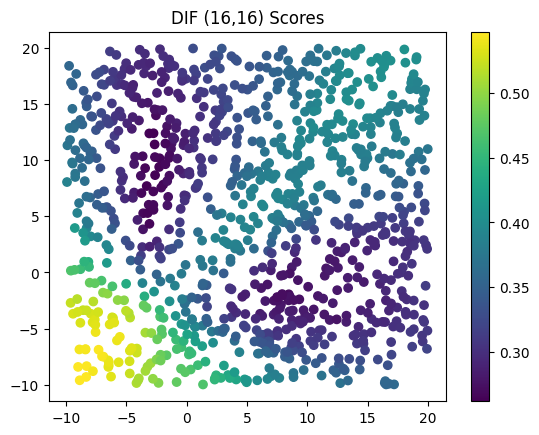

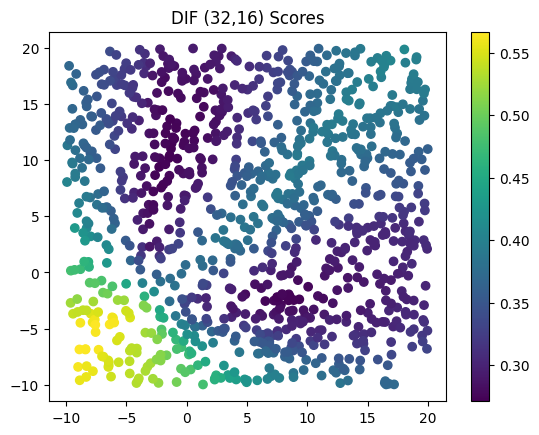

In [24]:
dif1 = DIF(hidden_neurons=[16, 16], contamination=0.02)
dif1.fit(points)
dif_scores1 = dif1.decision_function(test_data)
plt.scatter(test_data[:,0], test_data[:,1], c=dif_scores1, cmap="viridis")
plt.colorbar()
plt.title("DIF (16,16) Scores")
plt.show()

dif2 = DIF(hidden_neurons=[32, 16], contamination=0.02)
dif2.fit(points)
dif_scores2 = dif2.decision_function(test_data)
plt.scatter(test_data[:,0], test_data[:,1], c=dif_scores2, cmap="viridis")
plt.colorbar()
plt.title("DIF (32,16) Scores")
plt.show()

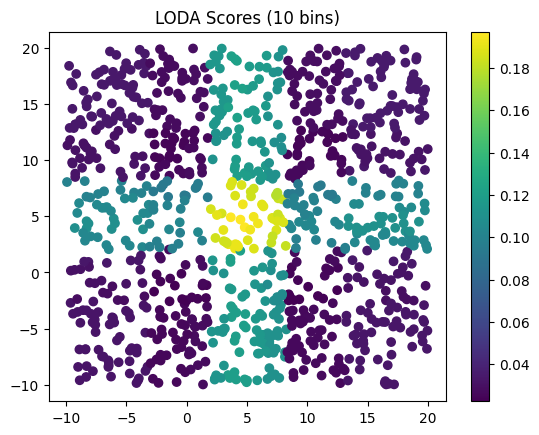

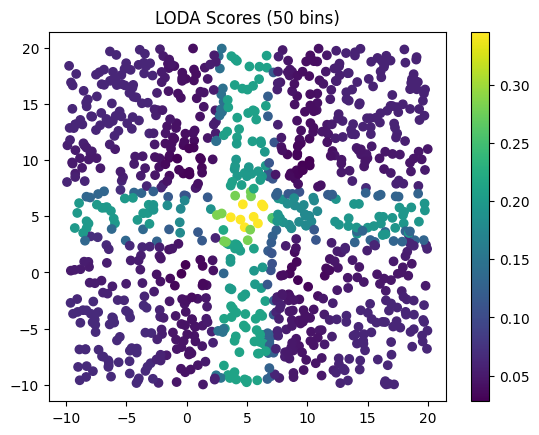

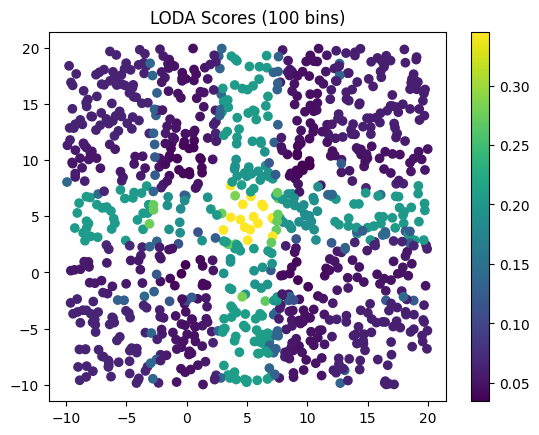

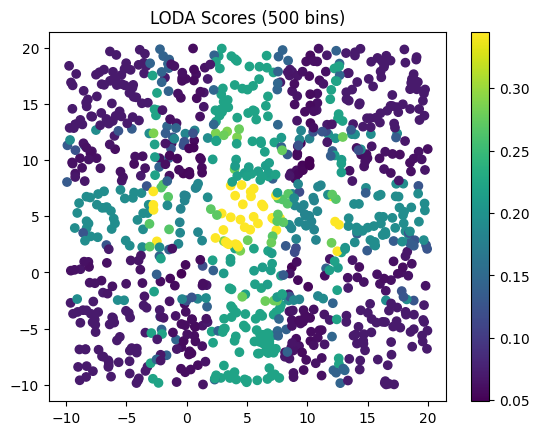

In [25]:
bin_options = [10, 50, 100, 500]
loda_scores = {}

for nb in bin_options:
    l = LODA(contamination=0.02, n_bins=nb)
    l.fit(points)
    loda_scores[nb] = l.decision_function(test_data)
    
for nb in bin_options:
    plt.scatter(test_data[:,0], test_data[:,1], c=loda_scores[nb], cmap="viridis")
    plt.colorbar()
    plt.title(f"LODA Scores ({nb} bins)")
    plt.show()

In [ ]:
#EX2 - 3D case

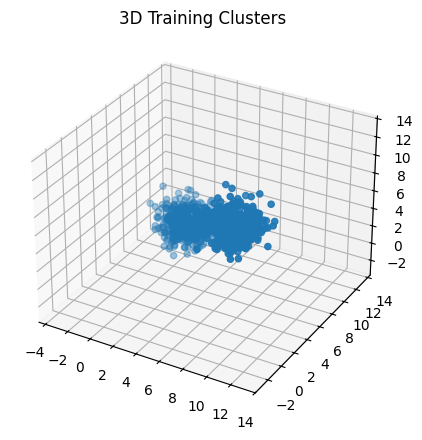

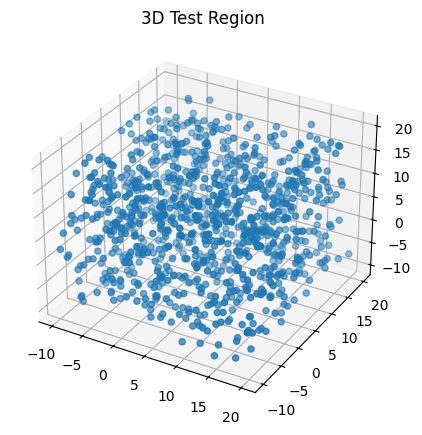

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from pyod.models.iforest import IForest
from pyod.models.dif import DIF
from pyod.models.loda import LODA
from mpl_toolkits.mplot3d import Axes3D

points3d, _ = make_blobs(
    n_samples=1000,
    n_features=3,
    centers=[(0, 10, 0), (10, 0, 10)],
    cluster_std=1.0,
    random_state=22
)

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points3d[:,0], points3d[:,1], points3d[:,2])
ax.set_title("3D Training Clusters")
plt.show()

rng = np.random.default_rng(33)
test3d = rng.uniform(-10, 20, size=(1000, 3))

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(test3d[:,0], test3d[:,1], test3d[:,2])
ax.set_title("3D Test Region")
plt.show()

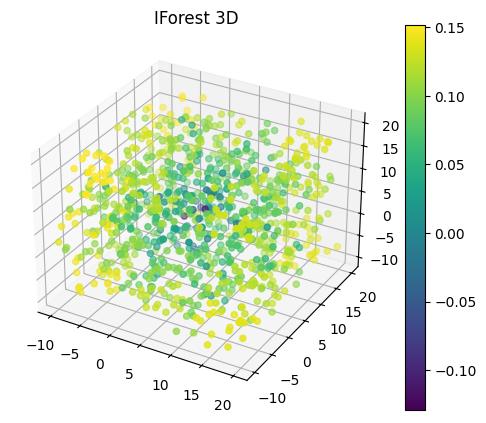

In [27]:
if3d = IForest(contamination=0.02)
if3d.fit(points3d)
scores_if3d = if3d.decision_function(test3d)

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(test3d[:,0], test3d[:,1], test3d[:,2], c=scores_if3d, cmap="viridis")
fig.colorbar(p)
ax.set_title("IForest 3D")
plt.show()

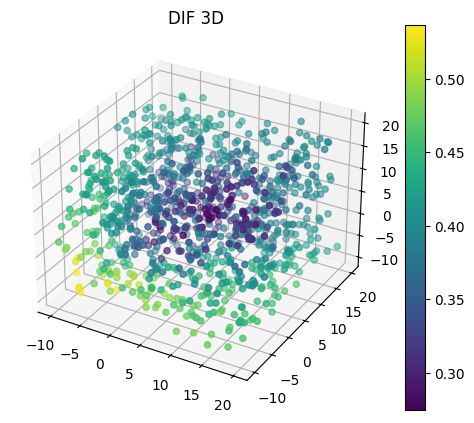

In [28]:
dif3d = DIF(hidden_neurons=[32, 16], contamination=0.02)
dif3d.fit(points3d)
scores_dif3d = dif3d.decision_function(test3d)

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(test3d[:,0], test3d[:,1], test3d[:,2], c=scores_dif3d, cmap="viridis")
fig.colorbar(p)
ax.set_title("DIF 3D")
plt.show()

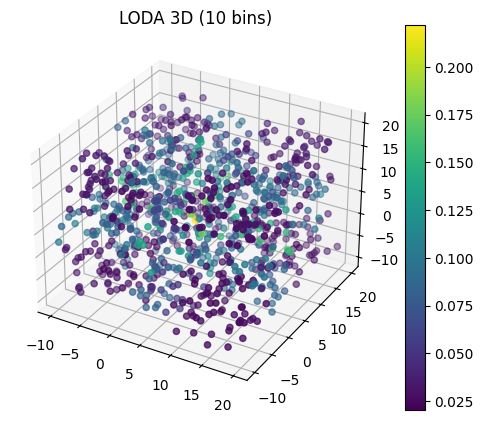

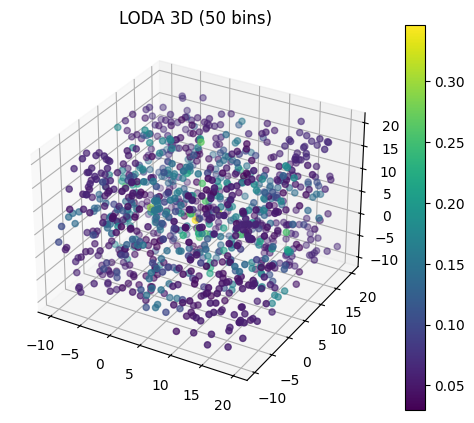

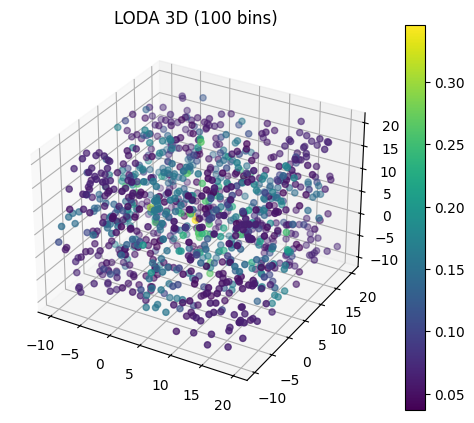

In [29]:
bins3d = [10, 50, 100]
loda_scores3d = {}

for b in bins3d:
    l = LODA(contamination=0.02, n_bins=b)
    l.fit(points3d)
    loda_scores3d[b] = l.decision_function(test3d)

for b in bins3d:
    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(111, projection='3d')
    p = ax.scatter(test3d[:,0], test3d[:,1], test3d[:,2], c=loda_scores3d[b], cmap="viridis")
    fig.colorbar(p)
    ax.set_title(f"LODA 3D ({b} bins)")
    plt.show()

In [ ]:
#EX3

In [36]:
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
import numpy as np
from pyod.models.iforest import IForest
from pyod.models.loda import LODA
from pyod.models.dif import DIF

data_raw = loadmat("shuttle.mat")
features = data_raw["X"]
labels = (data_raw["y"].ravel() != 1).astype(int)

runs = 10
acc_dict = {"IF": [], "DIF": [], "LODA": []}
roc_dict = {"IF": [], "DIF": [], "LODA": []}

for seed in range(runs):
    Xtr, Xte, ytr, yte = train_test_split(features, labels, test_size=0.4, stratify=labels, random_state=seed)
    norm = StandardScaler()
    Xtr_n = norm.fit_transform(Xtr)
    Xte_n = norm.transform(Xte)

    model_if = IForest(n_estimators=100, max_samples=256, contamination=0.02, random_state=seed)
    model_if.fit(Xtr_n)
    sc_if = model_if.decision_function(Xte_n)
    pred_if = model_if.predict(Xte_n)
    acc_dict["IF"].append(balanced_accuracy_score(yte, pred_if))
    roc_dict["IF"].append(roc_auc_score(yte, -sc_if))

    model_dif = DIF(n_ensemble=5, n_estimators=3, max_samples=256, contamination=0.02,
                    representation_dim=4, batch_size=256, random_state=seed, device="cpu")
    model_dif.fit(Xtr_n)
    sc_dif = model_dif.decision_function(Xte_n)
    pred_dif = model_dif.predict(Xte_n)
    acc_dict["DIF"].append(balanced_accuracy_score(yte, pred_dif))
    roc_dict["DIF"].append(roc_auc_score(yte, -sc_dif))

    model_l = LODA(n_bins=30, contamination=0.02)
    model_l.fit(Xtr_n)
    sc_l = model_l.decision_function(Xte_n)
    pred_l = model_l.predict(Xte_n)
    acc_dict["LODA"].append(balanced_accuracy_score(yte, pred_l))
    roc_dict["LODA"].append(roc_auc_score(yte, -sc_l))

for key in ["IF", "DIF", "LODA"]:
    print(key, "BA:", np.mean(acc_dict[key]), "AUC:", np.mean(roc_dict[key]))

IF BA: 0.35648151468209044 AUC: 0.9975172838464585
DIF BA: 0.49873991775623255 AUC: 0.9495001121008798
LODA BA: 0.3898690704688785 AUC: 0.7817584761154818
